In [ ]:
# ============================================================
# 🚢 SHIP DETECTION ON SAR IMAGES USING YOLOv8 (COLAB – ONE CELL)
# ============================================================

# -------------------------------
# 1️⃣ Install dependencies (safe versions)
# -------------------------------
!pip install -U ultralytics torch torchvision torchaudio --quiet

# -------------------------------
# 2️⃣ Imports
# -------------------------------
from ultralytics import YOLO
import zipfile, os, glob, yaml
from google.colab import files
import torch

print("✅ Torch version:", torch.__version__)

# -------------------------------
# 3️⃣ Upload dataset ZIP
# -------------------------------
print("\n📂 Upload YOLOv8 dataset ZIP")
print("⚠️ Must contain: train/, valid/, test/, data.yaml")
uploaded = files.upload()

dataset_zip = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {dataset_zip}")

# -------------------------------
# 4️⃣ Extract dataset
# -------------------------------
dataset_path = "/content/ship_dataset"
os.makedirs(dataset_path, exist_ok=True)

with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(dataset_path)

print("✅ Dataset extracted successfully")

# -------------------------------
# 5️⃣ Locate data.yaml
# -------------------------------
yaml_files = glob.glob(os.path.join(dataset_path, "**/*.yaml"), recursive=True)
if not yaml_files:
    raise FileNotFoundError("❌ data.yaml not found in dataset")

yaml_path = yaml_files[0]
print(f"🟢 Using dataset config: {yaml_path}")

# -------------------------------
# 6️⃣ Verify SHIP class
# -------------------------------
with open(yaml_path, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = [str(n).upper() for n in data_cfg.get("names", [])]
print("📌 Classes:", class_names)

if "SHIP" not in class_names:
    print("⚠️ Warning: 'SHIP' label not found")
else:
    print("✅ 'SHIP' label found")

# -------------------------------
# 7️⃣ Load YOLOv8s pretrained model
# -------------------------------
model = YOLO("yolov8s.pt")

# -------------------------------
# 8️⃣ Train model (150 epochs)
# -------------------------------
print("\n🚀 Training started...\n")

model.train(
    data=yaml_path,
    epochs=150,
    imgsz=640,
    batch=16,
    name="ship_detector_v8"
)

print("\n✅ Training completed\n")

# -------------------------------
# 9️⃣ Evaluate metrics
# -------------------------------
print("📊 Evaluating Precision, Recall, mAP@0.5...\n")

results = model.val(data=yaml_path, imgsz=640)

precision = float(results.box.p[0])
recall    = float(results.box.r[0])
map50     = float(results.box.map50)

print("====================================")
print("🚢 SHIP DETECTION METRICS")
print("====================================")
print(f"🔹 Precision : {precision:.4f}")
print(f"🔹 Recall    : {recall:.4f}")
print(f"🔹 mAP@0.5   : {map50:.4f}")
print("====================================")

# -------------------------------
# 🔟 Save & download trained model
# -------------------------------
best_model_path = "/content/runs/detect/ship_detector_v8/weights/best.pt"
final_model_path = "/content/ship_detector_model.pt"

if os.path.exists(best_model_path):
    os.rename(best_model_path, final_model_path)
    print(f"💾 Model saved as: {final_model_path}")

    files.download(final_model_path)
    print("⬇️ Model download started")

else:
    print("⚠️ best.pt not found")

print("\n🎯 ALL STEPS COMPLETED SUCCESSFULLY!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 703.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/

Saving EPICS DATASET.zip to EPICS DATASET.zip
✅ Uploaded file: EPICS DATASET.zip
✅ Dataset extracted successfully
🟢 Using dataset config: /content/ship_dataset/data.yaml
📌 Classes: ['SHIP']
✅ 'SHIP' label found

🚀 Training started...

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ship_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Model download started

🎯 ALL STEPS COMPLETED SUCCESSFULLY!


✅ Model loaded

📂 Upload a test image


Saving 640X640.jpg to 640X640 (3).jpg

image 1/1 /content/640X640 (3).jpg: 640x640 2 SHIPs, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


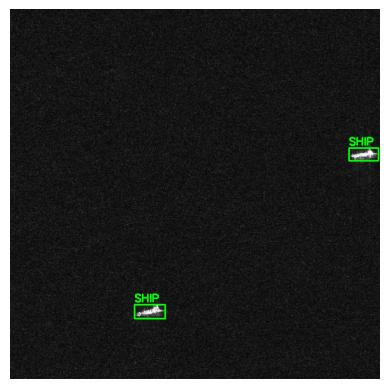

📄 YOLO FORMAT VALUES


,class,x_center,y_center,width,height
0,SHIP,0.377344,0.817187,0.082812,0.037500
1,SHIP,0.955469,0.392188,0.079687,0.034375


In [ ]:
# ============================================================
# 🧪 YOLOv8 TESTING (SINGLE IMAGE, CLEAN BBOX, YOLO FORMAT)
# ============================================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# -------------------------------
# 1️⃣ Load trained model
# -------------------------------
model = YOLO("/content/ship_detector_model.pt")
print("✅ Model loaded")

# -------------------------------
# 2️⃣ Upload test image
# -------------------------------
print("\n📂 Upload a test image")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# -------------------------------
# 3️⃣ Read image
# -------------------------------
img = cv2.imread(img_path)
if img is None:
    raise ValueError("❌ Image not readable")

h, w = img.shape[:2]

# -------------------------------
# 4️⃣ Run inference (with NMS)
# -------------------------------
results = model(img_path, conf=0.25, iou=0.5)[0]

yolo_outputs = []

# -------------------------------
# 5️⃣ Process detections
# -------------------------------
for box in results.boxes:
    xmin, ymin, xmax, ymax = map(int, box.xyxy[0])

    # Convert to YOLO format
    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h
    width    = (xmax - xmin) / w
    height   = (ymax - ymin) / h

    yolo_outputs.append({
        "class": "SHIP",
        "x_center": round(x_center, 6),
        "y_center": round(y_center, 6),
        "width": round(width, 6),
        "height": round(height, 6)
    })

    # Draw bounding box (ONLY ONCE)
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(
        img,
        "SHIP",
        (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# -------------------------------
# 6️⃣ Display image
# -------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# -------------------------------
# 7️⃣ Display YOLO format values
# -------------------------------
df = pd.DataFrame(yolo_outputs)

print("📄 YOLO FORMAT VALUES")
display(df)


✅ Model loaded

📂 Upload a test image


Saving P0001_0_800_10190_10990.jpg to P0001_0_800_10190_10990 (1).jpg

image 1/1 /content/P0001_0_800_10190_10990 (1).jpg: 640x640 1 SHIP, 16.3ms
Speed: 6.3ms preprocess, 16.3ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


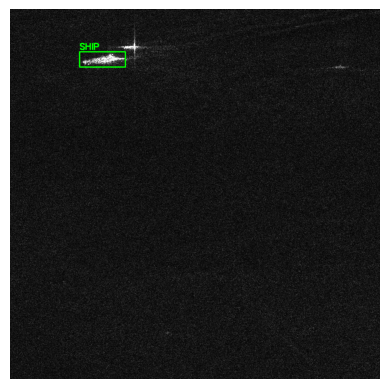

📄 YOLO FORMAT VALUES


,class,x_center,y_center,width,height
0,SHIP,0.249375,0.135625,0.12375,0.04125


In [ ]:
# ============================================================
# 🧪 YOLOv8 TESTING (SINGLE IMAGE, CLEAN BBOX, YOLO FORMAT)
# ============================================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# -------------------------------
# 1️⃣ Load trained model
# -------------------------------
model = YOLO("/content/ship_detector_model.pt")
print("✅ Model loaded")

# -------------------------------
# 2️⃣ Upload test image
# -------------------------------
print("\n📂 Upload a test image")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# -------------------------------
# 3️⃣ Read image
# -------------------------------
img = cv2.imread(img_path)
if img is None:
    raise ValueError("❌ Image not readable")

h, w = img.shape[:2]

# -------------------------------
# 4️⃣ Run inference (with NMS)
# -------------------------------
results = model(img_path, conf=0.25, iou=0.5)[0]

yolo_outputs = []

# -------------------------------
# 5️⃣ Process detections
# -------------------------------
for box in results.boxes:
    xmin, ymin, xmax, ymax = map(int, box.xyxy[0])

    # Convert to YOLO format
    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h
    width    = (xmax - xmin) / w
    height   = (ymax - ymin) / h

    yolo_outputs.append({
        "class": "SHIP",
        "x_center": round(x_center, 6),
        "y_center": round(y_center, 6),
        "width": round(width, 6),
        "height": round(height, 6)
    })

    # Draw bounding box (ONLY ONCE)
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(
        img,
        "SHIP",
        (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# -------------------------------
# 6️⃣ Display image
# -------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# -------------------------------
# 7️⃣ Display YOLO format values
# -------------------------------
df = pd.DataFrame(yolo_outputs)

print("📄 YOLO FORMAT VALUES")
display(df)


✅ Model loaded

📂 Upload a test image


Saving 000113_jpg.rf.39f9bbcc4447dd3d8b6ce6f345620c7e.jpg to 000113_jpg.rf.39f9bbcc4447dd3d8b6ce6f345620c7e.jpg

image 1/1 /content/000113_jpg.rf.39f9bbcc4447dd3d8b6ce6f345620c7e.jpg: 640x640 2 SHIPs, 16.2ms
Speed: 2.0ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


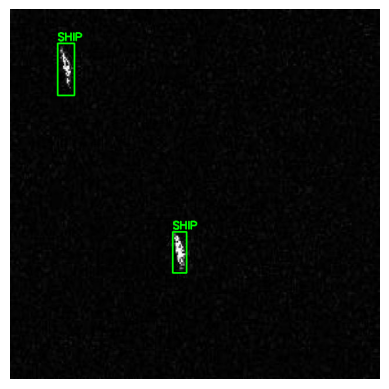

📄 YOLO FORMAT VALUES


,class,x_center,y_center,width,height
0,SHIP,0.457813,0.657031,0.037500,0.110937
1,SHIP,0.150781,0.162500,0.045312,0.140625


In [ ]:
# ============================================================
# 🧪 YOLOv8 TESTING (SINGLE IMAGE, CLEAN BBOX, YOLO FORMAT)
# ============================================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

# -------------------------------
# 1️⃣ Load trained model
# -------------------------------
model = YOLO("/content/ship_detector_model.pt")
print("✅ Model loaded")

# -------------------------------
# 2️⃣ Upload test image
# -------------------------------
print("\n📂 Upload a test image")
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# -------------------------------
# 3️⃣ Read image
# -------------------------------
img = cv2.imread(img_path)
if img is None:
    raise ValueError("❌ Image not readable")

h, w = img.shape[:2]

# -------------------------------
# 4️⃣ Run inference (with NMS)
# -------------------------------
results = model(img_path, conf=0.25, iou=0.5)[0]

yolo_outputs = []

# -------------------------------
# 5️⃣ Process detections
# -------------------------------
for box in results.boxes:
    xmin, ymin, xmax, ymax = map(int, box.xyxy[0])

    # Convert to YOLO format
    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h
    width    = (xmax - xmin) / w
    height   = (ymax - ymin) / h

    yolo_outputs.append({
        "class": "SHIP",
        "x_center": round(x_center, 6),
        "y_center": round(y_center, 6),
        "width": round(width, 6),
        "height": round(height, 6)
    })

    # Draw bounding box (ONLY ONCE)
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.putText(
        img,
        "SHIP",
        (xmin, ymin - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# -------------------------------
# 6️⃣ Display image
# -------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

# -------------------------------
# 7️⃣ Display YOLO format values
# -------------------------------
df = pd.DataFrame(yolo_outputs)

print("📄 YOLO FORMAT VALUES")
display(df)
